In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Shaallow Neural Network 

In [2]:
df = pd.read_excel("NGAsub_MegaFlatfile_RotD50_050_R211022_public.xlsx")

In [3]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam



# Filter conditions
df_filtered = df[(df['Earthquake_Magnitude'] >= 4) & 
                 (df['Rjb_km'] >= 0) & (df['Rjb_km'] <= 500) & 
                 (df['Vs30_Selected_for_Analysis_m_s'] > 0) & 
                 (df['Fault_Type'] > 0)].copy()

print(f"Original shape: {df.shape}, Filtered shape: {df_filtered.shape}")

# =========================
# 2. INPUT PREPARATION (X)
# =========================
df_filtered["Log_Vs30"] = np.log10(df_filtered["Vs30_Selected_for_Analysis_m_s"])
epsilon = 1e-3  
df_filtered["Log_R_Rup"] = np.log10(df_filtered["Rjb_km"] + epsilon)

X_numeric = df_filtered[["Earthquake_Magnitude", "Log_Vs30", "Rjb_km", "Log_R_Rup"]].values

encoder = OneHotEncoder(categories=[[1, 2, 3, 4]], sparse_output=False)
F_encoded = encoder.fit_transform(df_filtered[["Fault_Type"]])

X = np.hstack([X_numeric, F_encoded])
print("Input matrix shape (X):", X.shape)

# =========================
# 3. OUTPUT PREPARATION (Y)
# =========================
sa_cols = df_filtered.loc[:, "T0pt010S":"T20pt000S"].columns[:20]
output_cols = ["PGA_g", "PGV_cm_sec"] + list(sa_cols)
Y_raw = df_filtered[output_cols].values

# Mask rows with non-positive outputs
valid_mask = np.all(Y_raw > 0, axis=1)
print(f"Valid rows after Y check: {valid_mask.sum()}")

X = X[valid_mask]
Y = np.log10(Y_raw[valid_mask])

# =========================
# 4. SCALING & SPLITTING
# =========================
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)

X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y, test_size=0.2, random_state=42)
print(f"Training set: X={X_train.shape}, Y={Y_train.shape}")

# =========================
# 5. BASELINE SHALLOW NN
# =========================
print("\nTraining Baseline Shallow NN...")
model = Sequential([
    Dense(16, activation='relu', input_shape=(X_train.shape[1],)), # Single hidden layer = Shallow NN
    Dense(22, activation='linear')
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

history = model.fit(
    X_train, Y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=256,
    verbose=0 # Set to 0 to keep terminal clean, change to 1 if you want to see progress
)

# =========================
# 6. BASELINE EVALUATION
# =========================
test_loss, test_mae = model.evaluate(X_test, Y_test, verbose=0)
print(f"\nBaseline Test MSE: {test_loss:.4f}")
print(f"Baseline Test MAE: {test_mae:.4f}")

Y_pred = model.predict(X_test, verbose=0)
r2_overall = r2_score(Y_test, Y_pred, multioutput='variance_weighted')
print(f"Baseline Overall R²: {r2_overall:.4f}\n")

print("Per-output R² scores (First 5):")
r2_each = r2_score(Y_test, Y_pred, multioutput='raw_values')
for i in range(5):
    print(f"Output {i} ({output_cols[i]}): R² = {r2_each[i]:.3f}")

Original shape: (71340, 227), Filtered shape: (45675, 227)
Input matrix shape (X): (45675, 8)
Valid rows after Y check: 45607
Training set: X=(36485, 8), Y=(36485, 22)

Training Baseline Shallow NN...


c:\Users\vishnu vardhan\anaconda3\envs\tfenv\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Baseline Test MSE: 0.1635
Baseline Test MAE: 0.3095
Baseline Overall R²: 0.6711

Per-output R² scores (First 5):
Output 0 (PGA_g): R² = 0.684
Output 1 (PGV_cm_sec): R² = 0.768
Output 2 (T0pt010S): R² = 0.684
Output 3 (T0pt020S): R² = 0.684
Output 4 (T0pt022S): R² = 0.682


Per-output R² scores (All 22 parameters):
Output 00 (PGA_g     ): R² = 0.684
Output 01 (PGV_cm_sec): R² = 0.768
Output 02 (T0pt010S  ): R² = 0.684
Output 03 (T0pt020S  ): R² = 0.684
Output 04 (T0pt022S  ): R² = 0.682
Output 05 (T0pt025S  ): R² = 0.681
Output 06 (T0pt029S  ): R² = 0.680
Output 07 (T0pt030S  ): R² = 0.678
Output 08 (T0pt032S  ): R² = 0.676
Output 09 (T0pt035S  ): R² = 0.674
Output 10 (T0pt036S  ): R² = 0.674
Output 11 (T0pt040S  ): R² = 0.669
Output 12 (T0pt042S  ): R² = 0.666
Output 13 (T0pt044S  ): R² = 0.664
Output 14 (T0pt045S  ): R² = 0.664
Output 15 (T0pt046S  ): R² = 0.662
Output 16 (T0pt048S  ): R² = 0.661
Output 17 (T0pt050S  ): R² = 0.658
Output 18 (T0pt055S  ): R² = 0.651
Output 19 (T0pt060S  ): R² = 0.645
Output 20 (T0pt065S  ): R² = 0.639
Output 21 (T0pt067S  ): R² = 0.637


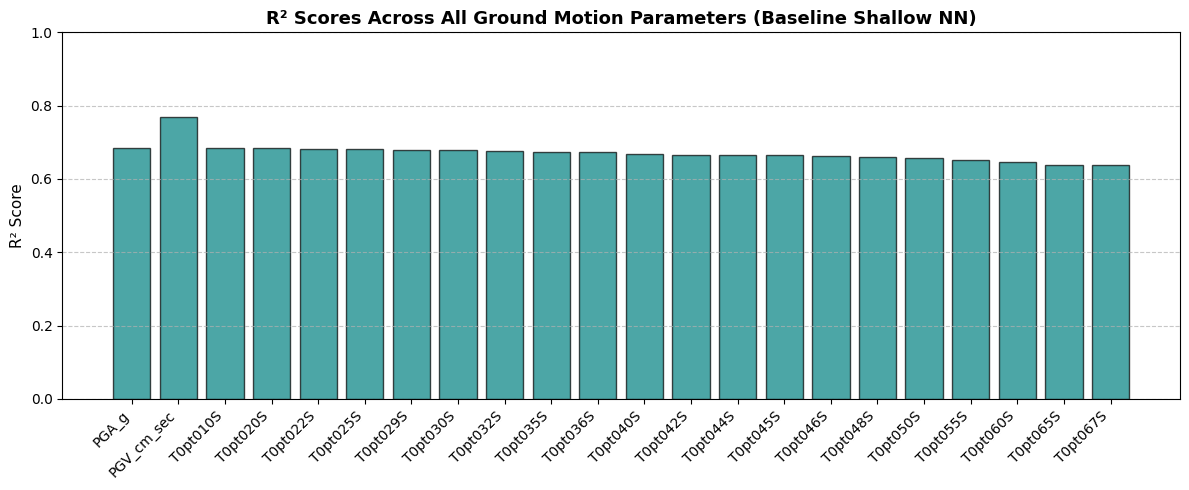

In [5]:
# =========================
# 6b. FULL R² CHECK & PLOT
# =========================
print("Per-output R² scores (All 22 parameters):")
for i, r2 in enumerate(r2_each):
    # The <10 formatting just aligns the text nicely in your console
    print(f"Output {i:02d} ({output_cols[i]:<10}): R² = {r2:.3f}")

# Visualizing the R² scores across all parameters
plt.figure(figsize=(12, 5))
bars = plt.bar(range(len(r2_each)), r2_each, color='teal', alpha=0.7, edgecolor='black')

# Set x-axis labels to the parameter names, rotated for readability
plt.xticks(range(len(r2_each)), output_cols, rotation=45, ha='right')

# Add labels and title
plt.ylabel("R² Score", fontsize=11)
plt.title("R² Scores Across All Ground Motion Parameters (Baseline Shallow NN)", fontsize=13, fontweight='bold')
plt.ylim(0, 1.0) # Assuming R2 is between 0 and 1 for your model

# Add a grid for easier reading
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Data extracted. Generating plots...


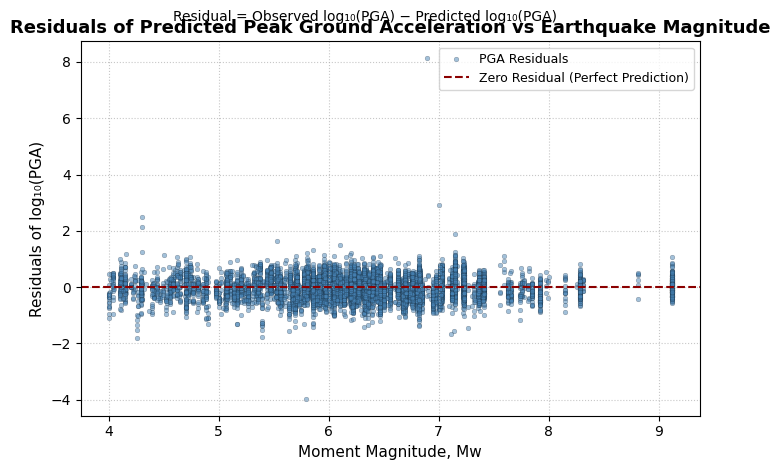

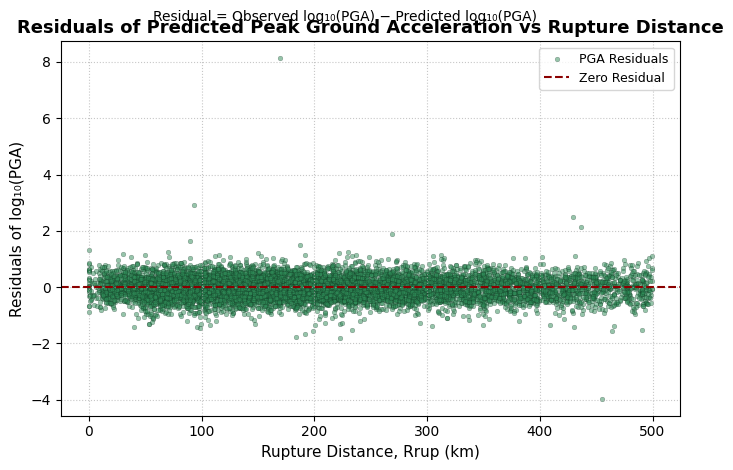

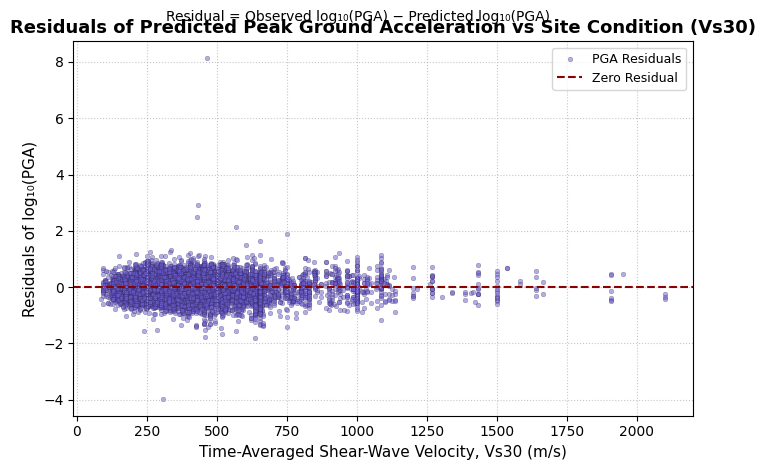

In [4]:
# =========================
# 7. CALCULATE RESIDUALS & EXTRACT TEST DATA
# =========================
# Residuals in log10 space
residuals = Y_test - Y_pred

# We will focus on PGA residuals (index 0) for these plots
res_pga = residuals[:, 0]

# To plot against the original unscaled inputs, we need the exact rows used in X_test
_, X_test_idx = train_test_split(
    np.arange(len(X_scaled)), # Using X_scaled length which is post-filtering
    test_size=0.2,
    random_state=42
)

# Extract unscaled test variables directly from the filtered dataframe
Mw_test = df_filtered.loc[valid_mask].iloc[X_test_idx]["Earthquake_Magnitude"].values
Rrup_test = df_filtered.loc[valid_mask].iloc[X_test_idx]["Rjb_km"].values
Vs30_test = df_filtered.loc[valid_mask].iloc[X_test_idx]["Vs30_Selected_for_Analysis_m_s"].values

print("Data extracted. Generating plots...")

# =========================
# 8. PLOT: RESIDUALS VS MAGNITUDE
# =========================
plt.figure(figsize=(7,5))
plt.scatter(
    Mw_test, res_pga, s=12, color='steelblue', alpha=0.5,
    edgecolor='k', linewidth=0.2, label='PGA Residuals'
)
plt.axhline(y=0, color='darkred', linestyle='--', linewidth=1.5, label='Zero Residual (Perfect Prediction)')

plt.xlabel("Moment Magnitude, Mw", fontsize=11)
plt.ylabel("Residuals of log₁₀(PGA)", fontsize=11)
plt.title("Residuals of Predicted Peak Ground Acceleration vs Earthquake Magnitude", fontsize=13, fontweight='bold')
plt.suptitle("Residual = Observed log₁₀(PGA) − Predicted log₁₀(PGA)", fontsize=10, y=0.93)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(frameon=True, fontsize=9)
plt.tight_layout()
plt.show()

# =========================
# 9. PLOT: RESIDUALS VS DISTANCE
# =========================
plt.figure(figsize=(7,5))
plt.scatter(
    Rrup_test, res_pga, s=12, color='seagreen', alpha=0.5,
    edgecolor='k', linewidth=0.2, label='PGA Residuals'
)
plt.axhline(y=0, color='darkred', linestyle='--', linewidth=1.5, label='Zero Residual')

plt.xlabel("Rupture Distance, Rrup (km)", fontsize=11)
plt.ylabel("Residuals of log₁₀(PGA)", fontsize=11)
plt.title("Residuals of Predicted Peak Ground Acceleration vs Rupture Distance", fontsize=13, fontweight='bold')
plt.suptitle("Residual = Observed log₁₀(PGA) − Predicted log₁₀(PGA)", fontsize=10, y=0.93)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(frameon=True, fontsize=9)
plt.tight_layout()
plt.show()

# =========================
# 10. PLOT: RESIDUALS VS VS30
# =========================
plt.figure(figsize=(7,5))
plt.scatter(
    Vs30_test, res_pga, s=12, color='slateblue', alpha=0.5,
    edgecolor='k', linewidth=0.2, label='PGA Residuals'
)
plt.axhline(y=0, color='darkred', linestyle='--', linewidth=1.5, label='Zero Residual')

plt.xlabel("Time-Averaged Shear-Wave Velocity, Vs30 (m/s)", fontsize=11)
plt.ylabel("Residuals of log₁₀(PGA)", fontsize=11)
plt.title("Residuals of Predicted Peak Ground Acceleration vs Site Condition (Vs30)", fontsize=13, fontweight='bold')
plt.suptitle("Residual = Observed log₁₀(PGA) − Predicted log₁₀(PGA)", fontsize=10, y=0.93)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(frameon=True, fontsize=9)
plt.tight_layout()
plt.show()


--- STEP 1: Tuning Hidden Neurons ---


c:\Users\vishnu vardhan\anaconda3\envs\tfenv\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Hidden neurons: 08 | Min Val MAE: 0.3126
Hidden neurons: 16 | Min Val MAE: 0.3072
Hidden neurons: 24 | Min Val MAE: 0.3069
Hidden neurons: 32 | Min Val MAE: 0.3063
Hidden neurons: 48 | Min Val MAE: 0.3068
Hidden neurons: 64 | Min Val MAE: 0.3046
>> Best Hidden Neurons: 64


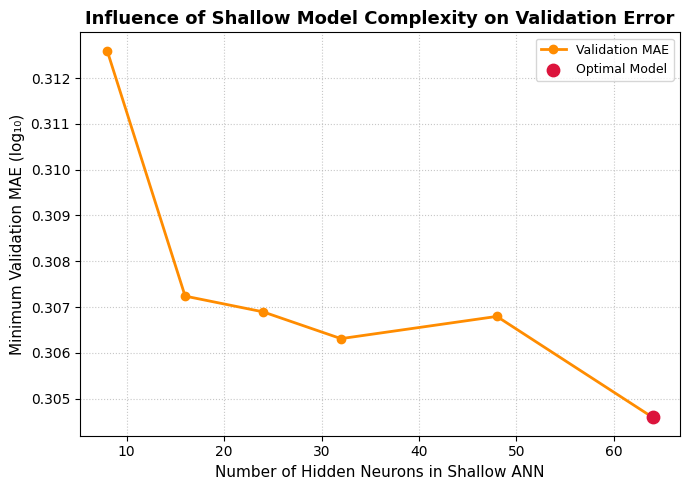

In [6]:
from tensorflow.keras.layers import Dropout

# ==========================================
# 11. TUNE NUMBER OF HIDDEN NEURONS
# ==========================================
print("\n--- STEP 1: Tuning Hidden Neurons ---")
hidden_units_list = [8, 16, 24, 32, 48, 64]
results_hidden = []

for H in hidden_units_list:
    model = Sequential([
        Dense(H, activation='relu', input_shape=(X_train.shape[1],)), # Still exactly 1 hidden layer
        Dense(22, activation='linear')
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    
    history = model.fit(
        X_train, Y_train, validation_split=0.2,
        epochs=60, batch_size=256, verbose=0 # Verbose=0 to avoid wall of text
    )
    
    min_val_mae = min(history.history['val_mae'])
    results_hidden.append((H, min_val_mae))
    print(f"Hidden neurons: {H:02d} | Min Val MAE: {min_val_mae:.4f}")

best_H = min(results_hidden, key=lambda x: x[1])[0]
print(f">> Best Hidden Neurons: {best_H}")

# Plot Hidden Neurons
Hs, maes = zip(*results_hidden)
plt.figure(figsize=(7,5))
plt.plot(Hs, maes, marker='o', markersize=6, linewidth=2, color='darkorange', label='Validation MAE')
best_idx = maes.index(min(maes))
plt.scatter(Hs[best_idx], maes[best_idx], color='crimson', s=80, zorder=5, label='Optimal Model')
plt.xlabel("Number of Hidden Neurons in Shallow ANN", fontsize=11)
plt.ylabel("Minimum Validation MAE (log₁₀)", fontsize=11)
plt.title("Influence of Shallow Model Complexity on Validation Error", fontsize=13, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(frameon=True, fontsize=9)
plt.tight_layout()
plt.show()




--- STEP 2: Tuning Learning Rate ---
LR: 0.0001 | Min Val MAE: 0.3176
LR: 0.0003 | Min Val MAE: 0.3090
LR: 0.0010 | Min Val MAE: 0.3054
LR: 0.0030 | Min Val MAE: 0.3051
LR: 0.0100 | Min Val MAE: 0.3033
>> Best Learning Rate: 0.01


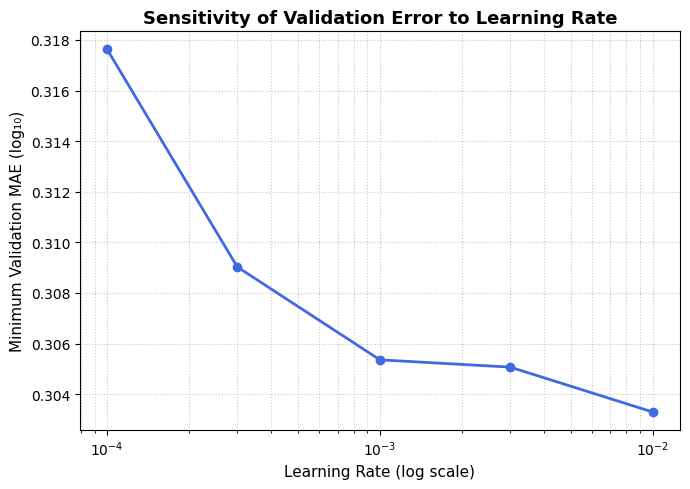

In [7]:
# ==========================================
# 12. TUNE LEARNING RATE
# ==========================================
print("\n--- STEP 2: Tuning Learning Rate ---")
lr_list = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2]
results_lr = []

for lr in lr_list:
    model = Sequential([
        Dense(best_H, activation='relu', input_shape=(X_train.shape[1],)),
        Dense(22, activation='linear')
    ])
    model.compile(optimizer=Adam(learning_rate=lr), loss='mse', metrics=['mae'])
    
    history = model.fit(
        X_train, Y_train, validation_split=0.2,
        epochs=60, batch_size=256, verbose=0
    )
    
    min_val_mae = min(history.history['val_mae'])
    results_lr.append((lr, min_val_mae))
    print(f"LR: {lr:.4f} | Min Val MAE: {min_val_mae:.4f}")

best_lr = min(results_lr, key=lambda x: x[1])[0]
print(f">> Best Learning Rate: {best_lr}")

# Plot Learning Rate
lrs, maes = zip(*results_lr)
plt.figure(figsize=(7,5))
plt.semilogx(lrs, maes, marker='o', markersize=6, linewidth=2, color='royalblue')
plt.xlabel("Learning Rate (log scale)", fontsize=11)
plt.ylabel("Minimum Validation MAE (log₁₀)", fontsize=11)
plt.title("Sensitivity of Validation Error to Learning Rate", fontsize=13, fontweight='bold')
plt.grid(True, which='both', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()




--- STEP 3: Tuning Batch Size ---
Batch size: 64   | Min Val MAE: 0.3054
Batch size: 128  | Min Val MAE: 0.3036
Batch size: 256  | Min Val MAE: 0.3040
Batch size: 512  | Min Val MAE: 0.3053
>> Best Batch Size: 128


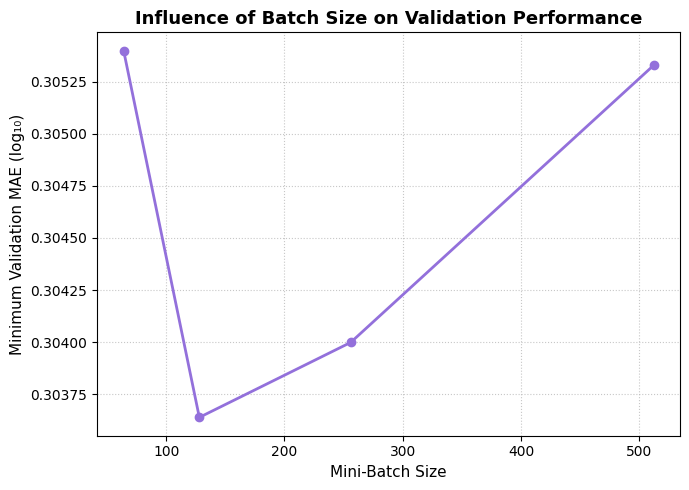

In [8]:
# ==========================================
# 13. TUNE BATCH SIZE
# ==========================================
print("\n--- STEP 3: Tuning Batch Size ---")
batch_sizes = [64, 128, 256, 512]
results_bs = []

for bs in batch_sizes:
    model = Sequential([
        Dense(best_H, activation='relu', input_shape=(X_train.shape[1],)),
        Dense(22, activation='linear')
    ])
    model.compile(optimizer=Adam(learning_rate=best_lr), loss='mse', metrics=['mae'])
    
    history = model.fit(
        X_train, Y_train, validation_split=0.2,
        epochs=60, batch_size=bs, verbose=0
    )
    
    min_val_mae = min(history.history['val_mae'])
    results_bs.append((bs, min_val_mae))
    print(f"Batch size: {bs:<4} | Min Val MAE: {min_val_mae:.4f}")

best_bs = min(results_bs, key=lambda x: x[1])[0]
print(f">> Best Batch Size: {best_bs}")

# Plot Batch Size
bss, maes = zip(*results_bs)
plt.figure(figsize=(7,5))
plt.plot(bss, maes, marker='o', markersize=6, linewidth=2, color='mediumpurple')
plt.xlabel("Mini-Batch Size", fontsize=11)
plt.ylabel("Minimum Validation MAE (log₁₀)", fontsize=11)
plt.title("Influence of Batch Size on Validation Performance", fontsize=13, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()




--- STEP 4: Tuning Dropout Rate ---
Dropout 0.0 | Min Val MAE: 0.3036
Dropout 0.1 | Min Val MAE: 0.3076
Dropout 0.2 | Min Val MAE: 0.3093
Dropout 0.3 | Min Val MAE: 0.3113
>> Best Dropout Rate: 0.0


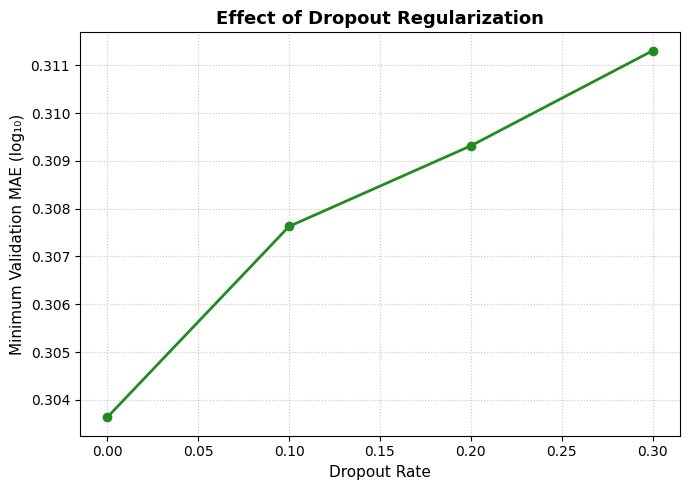


OPTIMAL HYPERPARAMETERS FOUND:
Neurons: 64 | LR: 0.01 | Batch Size: 128 | Dropout: 0.0


In [9]:
# ==========================================
# 14. TUNE DROPOUT RATE
# ==========================================
print("\n--- STEP 4: Tuning Dropout Rate ---")
dropout_list = [0.0, 0.1, 0.2, 0.3]
dropout_results = []

for dr in dropout_list:
    model = Sequential([
        Dense(best_H, activation='relu', input_shape=(X_train.shape[1],)),
        Dropout(dr), # Added dropout to prevent overfitting
        Dense(22, activation='linear')
    ])
    model.compile(optimizer=Adam(learning_rate=best_lr), loss='mse', metrics=['mae'])
    
    history = model.fit(
        X_train, Y_train, validation_split=0.2,
        epochs=60, batch_size=best_bs, verbose=0
    )
    
    min_val_mae = min(history.history['val_mae'])
    dropout_results.append((dr, min_val_mae))
    print(f"Dropout {dr:.1f} | Min Val MAE: {min_val_mae:.4f}")

best_dr = min(dropout_results, key=lambda x: x[1])[0]
print(f">> Best Dropout Rate: {best_dr}")

# Plot Dropout
drs, maes = zip(*dropout_results)
plt.figure(figsize=(7,5))
plt.plot(drs, maes, marker='o', markersize=6, linewidth=2, color='forestgreen')
plt.xlabel("Dropout Rate", fontsize=11)
plt.ylabel("Minimum Validation MAE (log₁₀)", fontsize=11)
plt.title("Effect of Dropout Regularization", fontsize=13, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

print("\n==============================================")
print(f"OPTIMAL HYPERPARAMETERS FOUND:")
print(f"Neurons: {best_H} | LR: {best_lr} | Batch Size: {best_bs} | Dropout: {best_dr}")
print("==============================================")


Training Final Optimized Shallow NN...


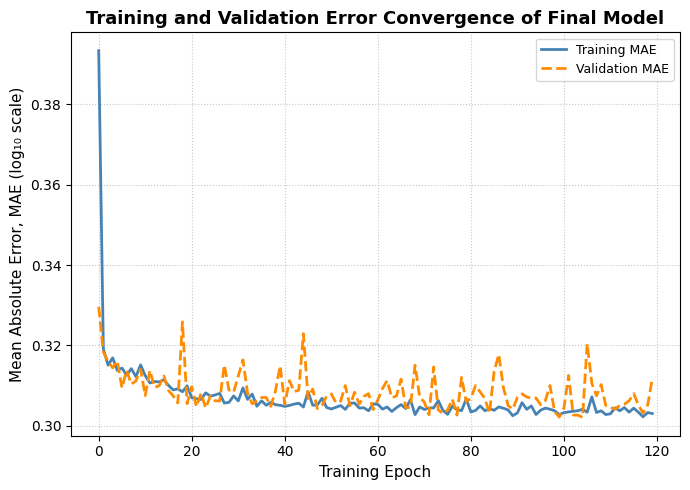


Final Test MSE: 0.1661
Final Test MAE: 0.3113
Final Overall R²: 0.6660

Final Per-output R² scores:
Output 00 (PGA_g     ): R² = 0.679
Output 01 (PGV_cm_sec): R² = 0.763
Output 02 (T0pt010S  ): R² = 0.678
Output 03 (T0pt020S  ): R² = 0.676
Output 04 (T0pt022S  ): R² = 0.676
Output 05 (T0pt025S  ): R² = 0.675
Output 06 (T0pt029S  ): R² = 0.673
Output 07 (T0pt030S  ): R² = 0.672
Output 08 (T0pt032S  ): R² = 0.671
Output 09 (T0pt035S  ): R² = 0.668
Output 10 (T0pt036S  ): R² = 0.667
Output 11 (T0pt040S  ): R² = 0.664
Output 12 (T0pt042S  ): R² = 0.662
Output 13 (T0pt044S  ): R² = 0.660
Output 14 (T0pt045S  ): R² = 0.659
Output 15 (T0pt046S  ): R² = 0.658
Output 16 (T0pt048S  ): R² = 0.656
Output 17 (T0pt050S  ): R² = 0.653
Output 18 (T0pt055S  ): R² = 0.647
Output 19 (T0pt060S  ): R² = 0.641
Output 20 (T0pt065S  ): R² = 0.635
Output 21 (T0pt067S  ): R² = 0.634


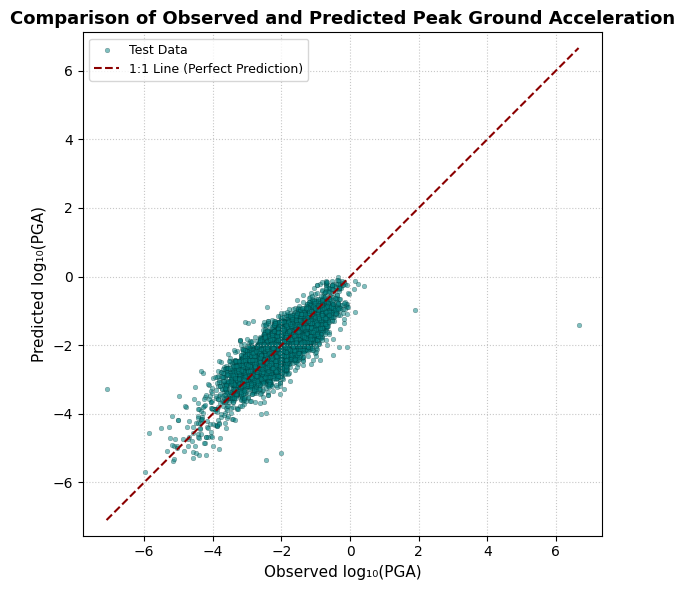

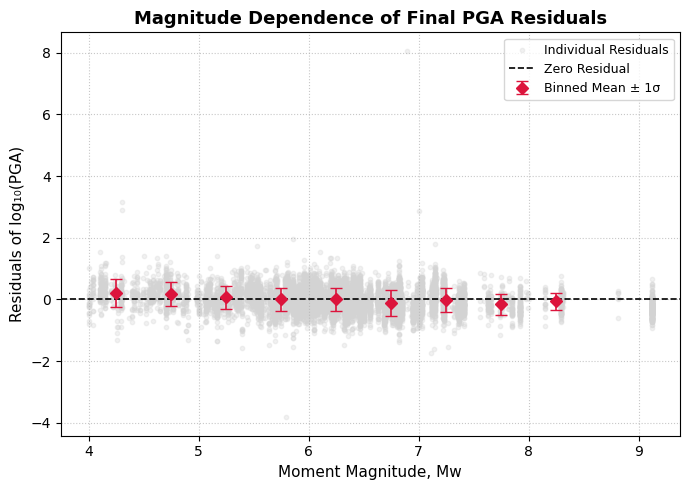

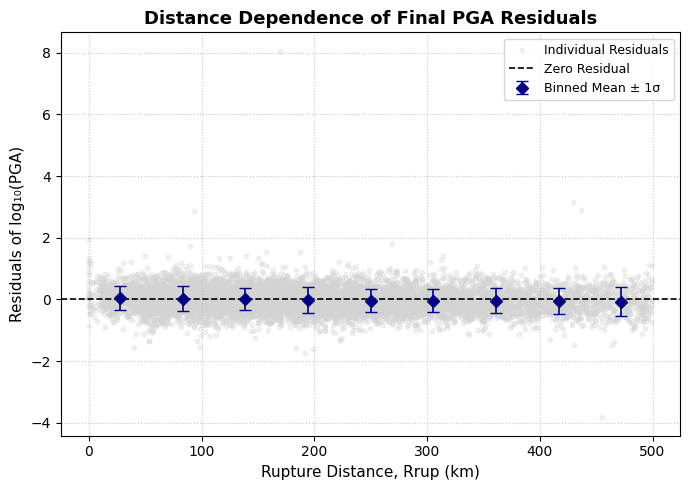

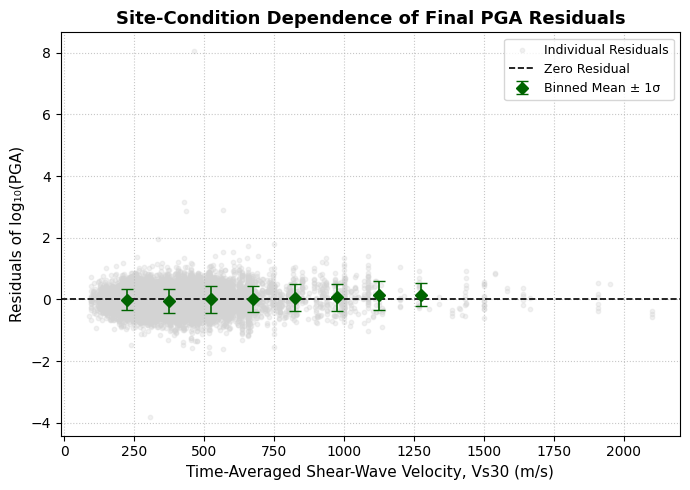

In [10]:
from tensorflow.keras.layers import Input

# ==========================================
# 15. TRAIN FINAL OPTIMIZED MODEL
# ==========================================
print("\nTraining Final Optimized Shallow NN...")

final_model = Sequential([
    Input(shape=(X_train.shape[1],)), # Fixes the Keras warning
    Dense(64, activation='relu'),     # Optimal Neurons
    Dense(22, activation='linear')
])

final_model.compile(
    optimizer=Adam(learning_rate=0.01), # Optimal Learning Rate
    loss='mse',
    metrics=['mae']
)

# Train slightly longer (120 epochs) to ensure full convergence with the new capacity
history_final = final_model.fit(
    X_train, Y_train,
    validation_split=0.2,
    epochs=120,          
    batch_size=128,      # Optimal Batch Size
    verbose=0            # Kept quiet for clean console
)

# ==========================================
# 16. LEARNING CURVE PLOT
# ==========================================
plt.figure(figsize=(7,5))
plt.plot(history_final.history['mae'], linewidth=2, color='steelblue', label='Training MAE')
plt.plot(history_final.history['val_mae'], linewidth=2, color='darkorange', linestyle='--', label='Validation MAE')
plt.xlabel("Training Epoch", fontsize=11)
plt.ylabel("Mean Absolute Error, MAE (log₁₀ scale)", fontsize=11)
plt.title("Training and Validation Error Convergence of Final Model", fontsize=13, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(frameon=True, fontsize=9)
plt.tight_layout()
plt.show()

# ==========================================
# 17. FINAL EVALUATION METRICS
# ==========================================
test_loss, test_mae = final_model.evaluate(X_test, Y_test, verbose=0)
print(f"\nFinal Test MSE: {test_loss:.4f}")
print(f"Final Test MAE: {test_mae:.4f}")

Y_test_pred = final_model.predict(X_test, verbose=0)

# Overall R²
r2_overall = r2_score(Y_test, Y_test_pred, multioutput='variance_weighted')
print(f"Final Overall R²: {r2_overall:.4f}\n")

# Per-output R²
print("Final Per-output R² scores:")
r2_each = r2_score(Y_test, Y_test_pred, multioutput='raw_values')
for i, r2 in enumerate(r2_each):
    print(f"Output {i:02d} ({output_cols[i]:<10}): R² = {r2:.3f}")

# ==========================================
# 18. 1:1 OBSERVED VS PREDICTED PLOT
# ==========================================
plt.figure(figsize=(6,6))
plt.scatter(
    Y_test[:, 0], Y_test_pred[:, 0],
    s=12, alpha=0.5, color='teal', edgecolor='k', linewidth=0.2, label='Test Data'
)

# 1:1 reference line
min_val = min(Y_test[:, 0].min(), Y_test_pred[:, 0].min())
max_val = max(Y_test[:, 0].max(), Y_test_pred[:, 0].max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--', color='darkred', linewidth=1.5, label='1:1 Line (Perfect Prediction)')

plt.xlabel("Observed log₁₀(PGA)", fontsize=11)
plt.ylabel("Predicted log₁₀(PGA)", fontsize=11)
plt.title("Comparison of Observed and Predicted Peak Ground Acceleration", fontsize=13, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(frameon=True, fontsize=9)
plt.axis('equal')
plt.tight_layout()
plt.show()

# ==========================================
# 19. BINNED RESIDUAL STATS (Mw, Rrup, Vs30)
# ==========================================
# Calculate new residuals based on the final model
res_pga_final = Y_test[:, 0] - Y_test_pred[:, 0]

def binned_stats(x, y, bins):
    bin_means, bin_stds, bin_centers = [], [], []
    for i in range(len(bins)-1):
        mask = (x >= bins[i]) & (x < bins[i+1])
        if np.sum(mask) > 20:  # avoid empty/noisy bins
            bin_means.append(np.mean(y[mask]))
            bin_stds.append(np.std(y[mask]))
            bin_centers.append(0.5 * (bins[i] + bins[i+1]))
    return np.array(bin_centers), np.array(bin_means), np.array(bin_stds)

# --- Binned Magnitude ---
bins_M = np.linspace(4, 8.5, 10)
bc, bm, bs = binned_stats(Mw_test, res_pga_final, bins_M)

plt.figure(figsize=(7,5))
plt.scatter(Mw_test, res_pga_final, s=10, alpha=0.3, color='lightgray', label='Individual Residuals')
plt.errorbar(bc, bm, yerr=bs, fmt='D', color='crimson', ecolor='crimson', elinewidth=1.2, capsize=4, markersize=6, label='Binned Mean ± 1σ')
plt.axhline(0, color='black', linestyle='--', linewidth=1.2, label='Zero Residual')
plt.xlabel("Moment Magnitude, Mw", fontsize=11)
plt.ylabel("Residuals of log₁₀(PGA)", fontsize=11)
plt.title("Magnitude Dependence of Final PGA Residuals", fontsize=13, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(frameon=True, fontsize=9)
plt.tight_layout()
plt.show()

# --- Binned Distance ---
bins_R = np.linspace(0, 500, 10)
bc, bm, bs = binned_stats(Rrup_test, res_pga_final, bins_R)

plt.figure(figsize=(7,5))
plt.scatter(Rrup_test, res_pga_final, s=10, alpha=0.3, color='lightgray', label='Individual Residuals')
plt.errorbar(bc, bm, yerr=bs, fmt='D', color='navy', ecolor='navy', elinewidth=1.2, capsize=4, markersize=6, label='Binned Mean ± 1σ')
plt.axhline(0, color='black', linestyle='--', linewidth=1.2, label='Zero Residual')
plt.xlabel("Rupture Distance, Rrup (km)", fontsize=11)
plt.ylabel("Residuals of log₁₀(PGA)", fontsize=11)
plt.title("Distance Dependence of Final PGA Residuals", fontsize=13, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(frameon=True, fontsize=9)
plt.tight_layout()
plt.show()

# --- Binned Vs30 ---
bins_V = np.linspace(150, 1500, 10)
bc, bm, bs = binned_stats(Vs30_test, res_pga_final, bins_V)

plt.figure(figsize=(7,5))
plt.scatter(Vs30_test, res_pga_final, s=10, alpha=0.3, color='lightgray', label='Individual Residuals')
plt.errorbar(bc, bm, yerr=bs, fmt='D', color='darkgreen', ecolor='darkgreen', elinewidth=1.2, capsize=4, markersize=6, label='Binned Mean ± 1σ')
plt.axhline(0, color='black', linestyle='--', linewidth=1.2, label='Zero Residual')
plt.xlabel("Time-Averaged Shear-Wave Velocity, Vs30 (m/s)", fontsize=11)
plt.ylabel("Residuals of log₁₀(PGA)", fontsize=11)
plt.title("Site-Condition Dependence of Final PGA Residuals", fontsize=13, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(frameon=True, fontsize=9)
plt.tight_layout()
plt.show()

c:\Users\vishnu vardhan\anaconda3\envs\tfenv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Running Parametric Studies...


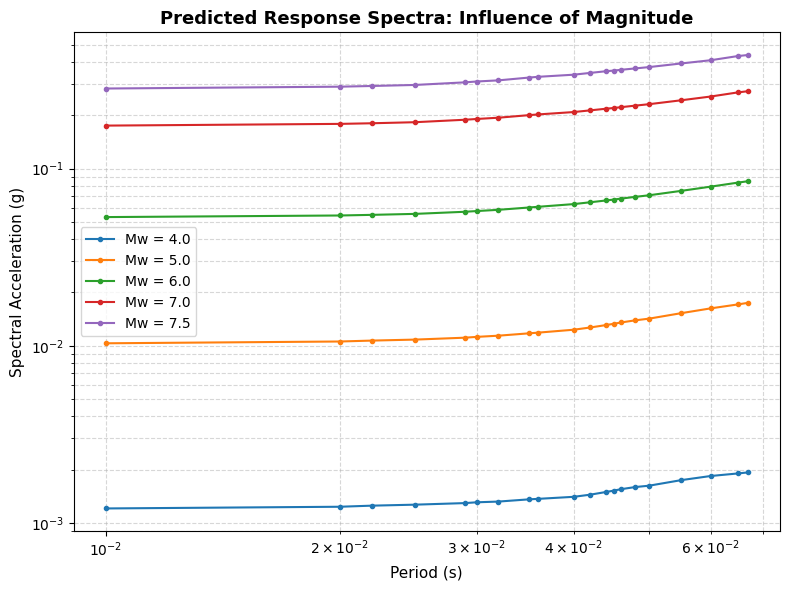

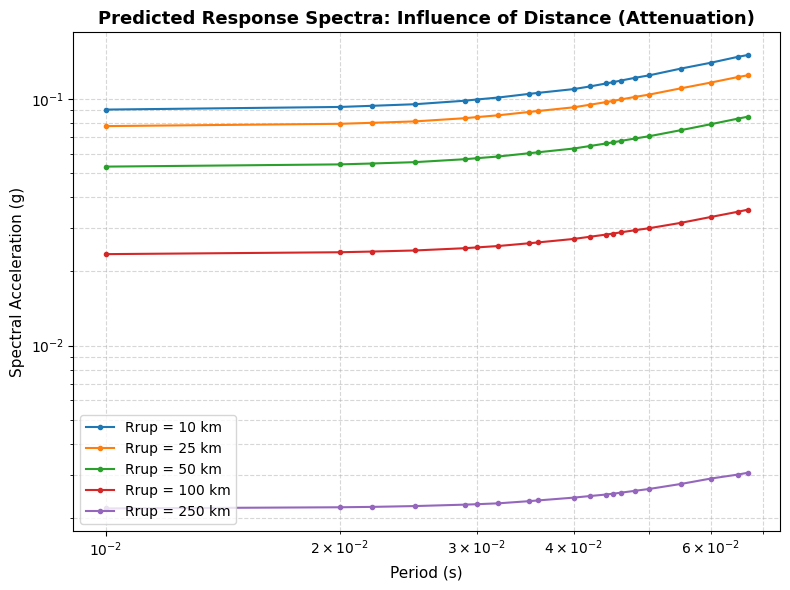

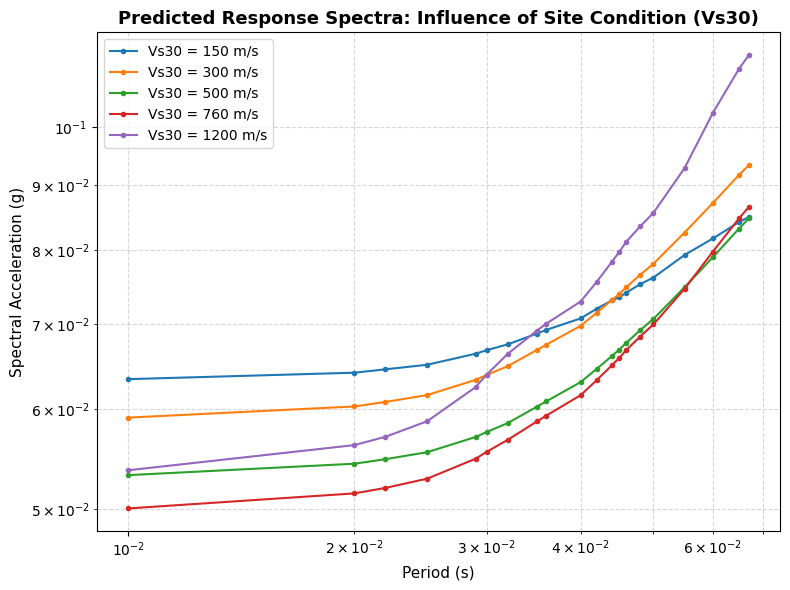


Calculating SHAP Values (This might take a minute)...


c:\Users\vishnu vardhan\anaconda3\envs\tfenv\lib\site-packages\shap\explainers\_deep\deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
c:\Users\vishnu vardhan\anaconda3\envs\tfenv\lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_64
Received: inputs=['Tensor(shape=(100, 8))']
  warnings.warn(msg)
c:\Users\vishnu vardhan\anaconda3\envs\tfenv\lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_64
Received: inputs=['Tensor(shape=(200, 8))']
  warnings.warn(msg)


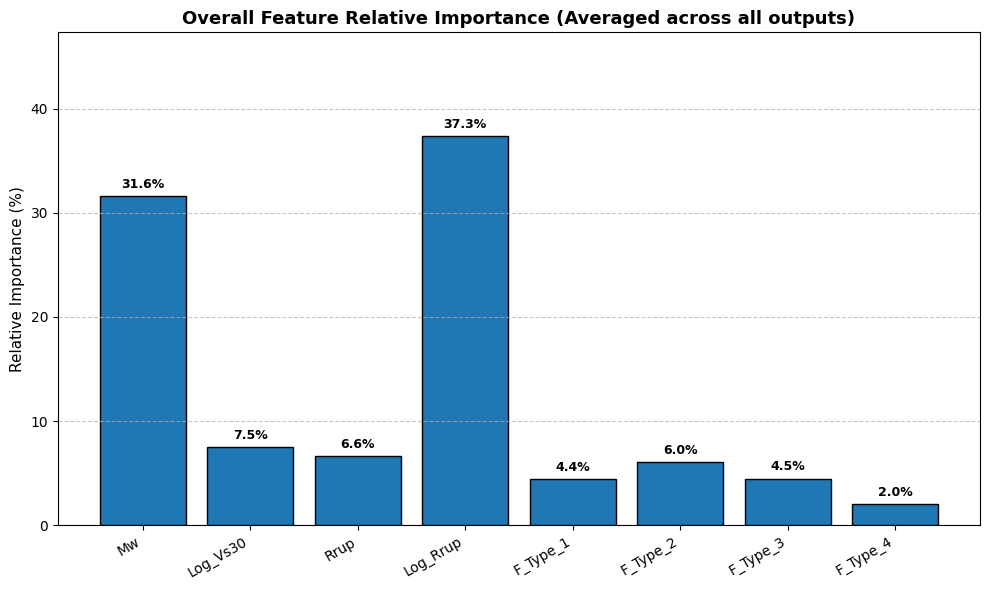

Generating SHAP Summary Plot for PGA...


C:\Users\vishnu vardhan\AppData\Local\Temp\ipykernel_28084\2937405611.py:138: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[0], X_test_sample, feature_names=feature_names, show=False)


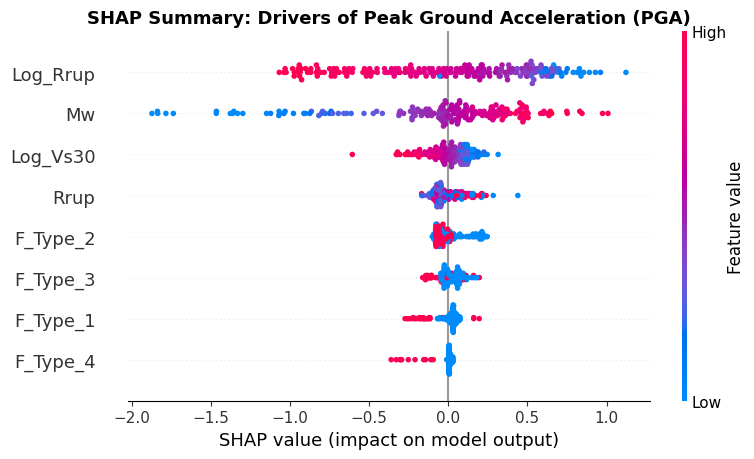

In [11]:
import re
import shap

# ==========================================
# 20. PREPARE PARAMETRIC STUDIES
# ==========================================
print("\nRunning Parametric Studies...")

# Extract numerical periods from your sa_cols (e.g., 'T0pt010S' -> 0.010)
periods = []
for col in sa_cols:
    val = col.replace('T', '').replace('S', '').replace('pt', '.')
    periods.append(float(val))
periods = np.array(periods)

# Set up baseline inputs for the parametric study (Average/Typical Scenario)
base_M = 6.0
base_V = 500.0  # m/s (approx. NEHRP Site Class C/D boundary)
base_R = 50.0   # km
base_F = np.array([[1, 0, 0, 0]]) # Assuming Fault_Type 1 as baseline

epsilon = 1e-3

# Function to generate a scaled input row for prediction
def create_input_row(M, R, V, F):
    log_V = np.log10(V)
    log_R = np.log10(R + epsilon)
    row_num = np.array([[M, log_V, R, log_R]])
    row = np.hstack([row_num, F])
    return scaler_X.transform(row)

# --- A) Parametric Study w.r.t Magnitude ---
M_list = [4.0, 5.0, 6.0, 7.0, 7.5]
plt.figure(figsize=(8, 6))
for M in M_list:
    row_scaled = create_input_row(M, base_R, base_V, base_F)
    pred_log_Y = final_model.predict(row_scaled, verbose=0)[0]
    pred_SA = 10**pred_log_Y[2:] # Skip PGA and PGV (indices 0 and 1), take only SA values
    plt.loglog(periods, pred_SA, marker='.', label=f'Mw = {M}')

plt.xlabel('Period (s)', fontsize=11)
plt.ylabel('Spectral Acceleration (g)', fontsize=11)
plt.title('Predicted Response Spectra: Influence of Magnitude', fontsize=13, fontweight='bold')
plt.legend(frameon=True)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

# --- B) Parametric Study w.r.t Rupture Distance ---
R_list = [10, 25, 50, 100, 250]
plt.figure(figsize=(8, 6))
for R in R_list:
    row_scaled = create_input_row(base_M, R, base_V, base_F)
    pred_log_Y = final_model.predict(row_scaled, verbose=0)[0]
    pred_SA = 10**pred_log_Y[2:] 
    plt.loglog(periods, pred_SA, marker='.', label=f'Rrup = {R} km')

plt.xlabel('Period (s)', fontsize=11)
plt.ylabel('Spectral Acceleration (g)', fontsize=11)
plt.title('Predicted Response Spectra: Influence of Distance (Attenuation)', fontsize=13, fontweight='bold')
plt.legend(frameon=True)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

# --- C) Parametric Study w.r.t Velocity (Vs30) ---
V_list = [150, 300, 500, 760, 1200]
plt.figure(figsize=(8, 6))
for V in V_list:
    row_scaled = create_input_row(base_M, base_R, V, base_F)
    pred_log_Y = final_model.predict(row_scaled, verbose=0)[0]
    pred_SA = 10**pred_log_Y[2:]
    plt.loglog(periods, pred_SA, marker='.', label=f'Vs30 = {V} m/s')

plt.xlabel('Period (s)', fontsize=11)
plt.ylabel('Spectral Acceleration (g)', fontsize=11)
plt.title('Predicted Response Spectra: Influence of Site Condition (Vs30)', fontsize=13, fontweight='bold')
plt.legend(frameon=True)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


# ==========================================
# 21. SHAP FEATURE IMPORTANCE ANALYSIS
# ==========================================
print("\nCalculating SHAP Values (This might take a minute)...")

feature_names = ["Mw", "Log_Vs30", "Rrup", "Log_Rrup", "F_Type_1", "F_Type_2", "F_Type_3", "F_Type_4"]

# Sample background data for the Explainer (to save computation time)
np.random.seed(42)
background_idx = np.random.choice(X_train.shape[0], 100, replace=False)
background = X_train[background_idx]

# Sample from test set to explain
test_idx = np.random.choice(X_test.shape[0], 200, replace=False)
X_test_sample = X_test[test_idx]

# Initialize DeepExplainer
explainer = shap.DeepExplainer(final_model, background)
shap_values_raw = explainer.shap_values(X_test_sample)

# Format SHAP values safely across different library versions
if isinstance(shap_values_raw, np.ndarray) and len(shap_values_raw.shape) == 3:
    shap_values = [shap_values_raw[:, :, i] for i in range(shap_values_raw.shape[2])]
elif hasattr(shap_values_raw, 'values') and len(shap_values_raw.values.shape) == 3:
    shap_values = [shap_values_raw.values[:, :, i] for i in range(shap_values_raw.values.shape[2])]
else:
    shap_values = shap_values_raw

# Aggregate mean absolute SHAP values across all 22 outputs and instances
mean_abs_shap = np.zeros(X_scaled.shape[1])
for i in range(len(shap_values)):
    mean_abs_shap += np.mean(np.abs(shap_values[i]), axis=0)

# Calculate percentages
rel_importance = 100 * mean_abs_shap / np.sum(mean_abs_shap)

# --- Plot: Overall Feature Importance Bar Chart ---
plt.figure(figsize=(10, 6))
bars = plt.bar(feature_names, rel_importance, color='#1f77b4', edgecolor='black')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f"{yval:.1f}%", ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.ylabel("Relative Importance (%)", fontsize=11)
plt.title("Overall Feature Relative Importance (Averaged across all outputs)", fontsize=13, fontweight='bold')
plt.ylim(0, max(rel_importance) + 10)
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# --- Plot: SHAP Summary for PGA (Output 0) ---
print("Generating SHAP Summary Plot for PGA...")
plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values[0], X_test_sample, feature_names=feature_names, show=False)
plt.title("SHAP Summary: Drivers of Peak Ground Acceleration (PGA)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Plotting SHAP for PGV (Output 1)...


C:\Users\vishnu vardhan\AppData\Local\Temp\ipykernel_28084\4024103969.py:7: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[1], X_test_sample, feature_names=feature_names, show=False)


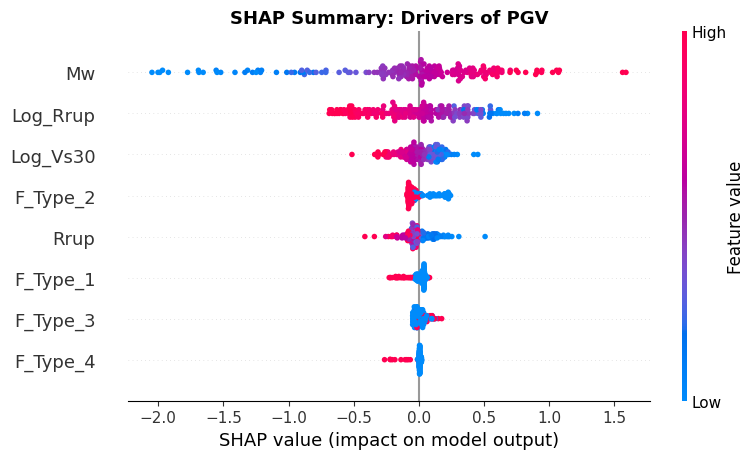

Plotting SHAP for PSA at 0.2s (Output 21)...


C:\Users\vishnu vardhan\AppData\Local\Temp\ipykernel_28084\4024103969.py:14: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[idx_02s], X_test_sample, feature_names=feature_names, show=False)


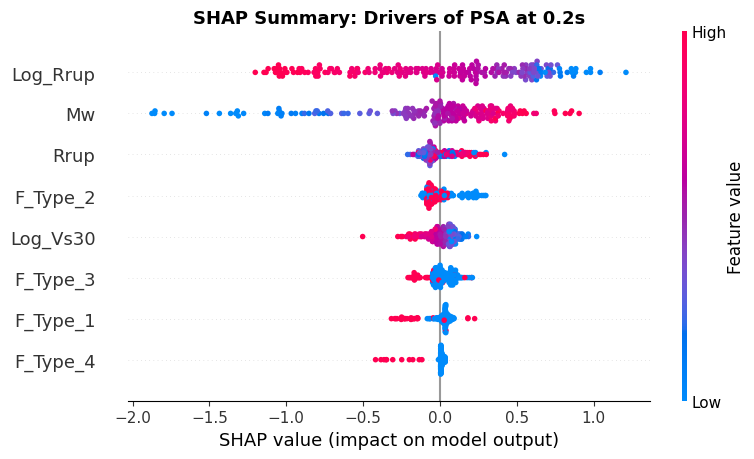

Plotting SHAP for PSA at 1s (Output 21)...


C:\Users\vishnu vardhan\AppData\Local\Temp\ipykernel_28084\4024103969.py:21: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[idx_1s], X_test_sample, feature_names=feature_names, show=False)


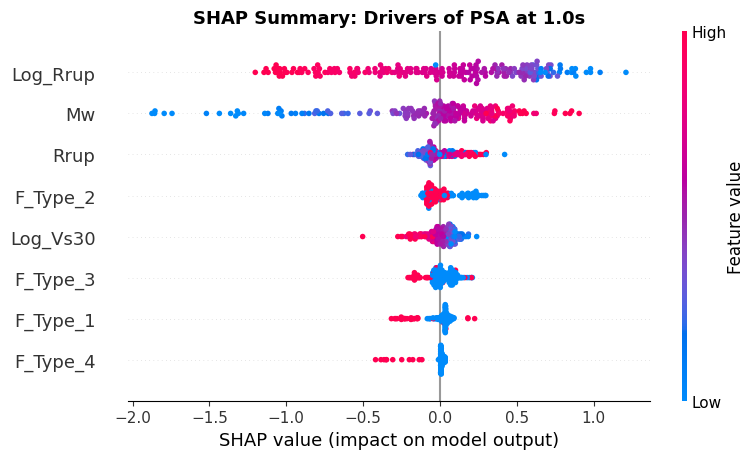

In [12]:
# Find the specific column indices for PSA 0.2s and 1.0s
idx_02s = 2 + np.argmin(np.abs(periods - 0.2)) 
idx_1s = 2 + np.argmin(np.abs(periods - 1.0))  

print("Plotting SHAP for PGV (Output 1)...")
plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values[1], X_test_sample, feature_names=feature_names, show=False)
plt.title("SHAP Summary: Drivers of PGV", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Plotting SHAP for PSA at 0.2s (Output {idx_02s})...")
plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values[idx_02s], X_test_sample, feature_names=feature_names, show=False)
plt.title("SHAP Summary: Drivers of PSA at 0.2s", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Plotting SHAP for PSA at 1s (Output {idx_1s})...")
plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values[idx_1s], X_test_sample, feature_names=feature_names, show=False)
plt.title("SHAP Summary: Drivers of PSA at 1.0s", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()